# 💳 Credit Card Fraud Detection System
### B.Tech ML Project — Core Python & Fundamental Algorithms (No sklearn)
**Dataset:** sample_10k.csv | **Models:** 5 Classifiers + 5 Regressors | **Metrics:** 50+ per model

---
> **Libraries allowed:** `numpy`, `pandas`, `matplotlib` only.  
> All algorithms, metrics, preprocessing, and evaluation are implemented **from scratch**.


## 0. Imports & Reproducibility

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, time
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print("Libraries loaded. Seed =", SEED)


Libraries loaded. Seed = 42


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sample_10k.csv to sample_10k.csv


## 1. Load Dataset

In [ ]:
df = pd.read_csv('balanced_10k.csv')

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")

df.head()

Shape: (10000, 31)

Class distribution:
Class
0    5000
1    5000
Name: count, dtype: int64

Fraud rate: 50.0000%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,170693.0,0.159430,1.063894,-0.484149,-0.595573,1.054702,-0.703502,1.009192,-0.126183,-0.108844,...,-0.349183,-0.833489,0.066363,0.383296,-0.375121,0.123712,0.224849,0.083378,4.49,0
1,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1
2,133184.0,-1.212682,-2.484824,-6.397186,3.670562,-0.863375,-1.855855,1.017732,-0.544704,-1.703378,...,1.396872,0.092073,-1.492882,-0.204227,0.532511,-0.293871,0.212663,0.431095,1335.00,1
3,148053.0,1.261324,2.726800,-5.435019,5.342759,1.447043,-1.442584,-0.898702,0.123062,-2.748496,...,0.209086,-0.425938,-0.154440,-0.018820,0.632234,0.192922,0.468181,0.280486,1.59,1
4,93853.0,-5.839192,7.151532,-12.816760,7.031115,-9.651272,-2.938427,-11.543207,4.843627,-3.494276,...,2.462056,1.054865,0.530481,0.472670,-0.275998,0.282435,0.104886,0.254417,316.06,1


## 2. Exploratory Data Analysis

=== Basic Statistics ===
             mean        std     min         max
Time    87949.699  48086.131  23.000  172703.000
V1         -2.350      5.400 -30.552       2.370
V2          1.787      3.663 -29.336      22.058
V3         -3.462      6.104 -31.104       3.770
V4          2.262      3.196  -4.790      12.115
V5         -1.513      4.144 -22.106      28.517
V6         -0.685      1.755 -17.282      10.154
V7         -2.735      5.787 -43.557      15.916
V8          0.222      4.947 -41.044      20.007
V9         -1.271      2.316 -13.434       6.950
V10        -2.799      4.527 -24.588      11.166
V11         1.899      2.767  -3.367      12.019
V12        -3.110      4.595 -18.684       3.162
V13        -0.053      1.055  -3.449       3.530
V14        -3.502      4.683 -19.214       5.210
V15        -0.040      0.979  -4.499       3.881
V16        -2.061      3.500 -14.130       3.802
V17        -3.303      6.000 -25.163       6.739
V18        -1.116      2.420  -9.499       3

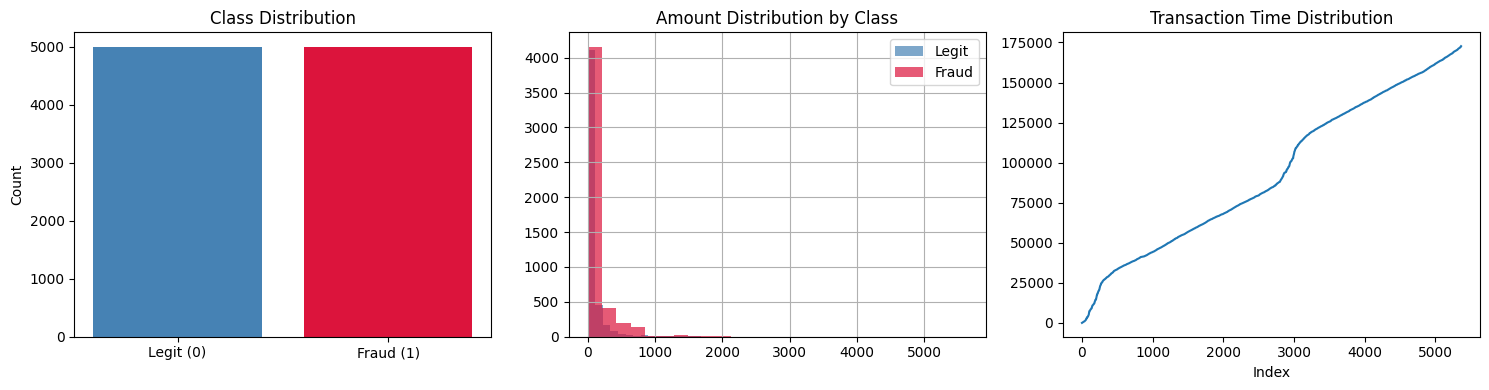

In [ ]:
print("=== Basic Statistics ===")
print(df.describe().T[['mean','std','min','max']].round(3))

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values")

# Amount distribution per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(['Legit (0)', 'Fraud (1)'], df['Class'].value_counts().values, color=['steelblue','crimson'])
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')

df[df['Class']==0]['Amount'].hist(bins=50, ax=axes[1], color='steelblue', alpha=0.7, label='Legit')
df[df['Class']==1]['Amount'].hist(bins=10, ax=axes[1], color='crimson', alpha=0.7, label='Fraud')
axes[1].set_title('Amount Distribution by Class'); axes[1].legend()

axes[2].plot(sorted(df['Time'].unique()), label='Time range')
axes[2].set_title('Transaction Time Distribution'); axes[2].set_xlabel('Index')
plt.tight_layout(); plt.show()


## 3. Preprocessing (`preprocessing.py` logic)
Manual normalization, outlier detection, train-test split — all with numpy only.


In [ ]:
# ── preprocessing.py ──────────────────────────────────────────────────────

def handle_missing(X, strategy='mean'):
    """Fill missing values with column mean/median/zero."""
    X = X.copy().astype(float)
    for j in range(X.shape[1]):
        mask = np.isnan(X[:, j])
        if mask.any():
            if strategy == 'mean':   fill = np.nanmean(X[:, j])
            elif strategy == 'median': fill = np.nanmedian(X[:, j])
            else:                    fill = 0.0
            X[mask, j] = fill
    return X

def minmax_normalize(X, feature_range=(0, 1)):
    """Min-Max normalization to [a, b]."""
    a, b = feature_range
    mins = X.min(axis=0); maxs = X.max(axis=0)
    denom = np.where(maxs - mins == 0, 1, maxs - mins)
    return a + (X - mins) / denom * (b - a), mins, maxs

def standardize(X):
    """Z-score standardization."""
    mu = X.mean(axis=0); sigma = X.std(axis=0)
    sigma = np.where(sigma == 0, 1, sigma)
    return (X - mu) / sigma, mu, sigma

def detect_outliers_iqr(X, k=1.5):
    """Return boolean mask True = outlier row (any feature)."""
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR; upper = Q3 + k * IQR
    return np.any((X < lower) | (X > upper), axis=1)

def train_test_split_manual(X, y, test_size=0.2, seed=42):
    """Stratified-ish manual split preserving minority class ratio."""
    rng = np.random.RandomState(seed)
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    rng.shuffle(idx0); rng.shuffle(idx1)
    n0_test = max(1, int(len(idx0) * test_size))
    n1_test = max(1, int(len(idx1) * test_size))
    test_idx  = np.concatenate([idx0[:n0_test], idx1[:n1_test]])
    train_idx = np.concatenate([idx0[n0_test:], idx1[n1_test:]])
    rng.shuffle(train_idx); rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

print("Preprocessing functions defined.")


Preprocessing functions defined.


## 4. Feature Engineering (`feature_engineering.py` logic)
Manual feature selection using variance, correlation, and mutual-information proxy.


In [ ]:
# ── feature_engineering.py ────────────────────────────────────────────────

def variance_filter(X, threshold=0.01):
    """Remove near-zero variance features."""
    variances = X.var(axis=0)
    return np.where(variances > threshold)[0]

def correlation_filter(X, threshold=0.95):
    """Remove highly correlated features (keep first of pair)."""
    corr = np.corrcoef(X.T)
    n = corr.shape[0]
    to_drop = set()
    for i in range(n):
        for j in range(i+1, n):
            if abs(corr[i, j]) > threshold:
                to_drop.add(j)
    return [i for i in range(n) if i not in to_drop]

def mutual_info_proxy(X, y, bins=10):
    """Entropy-based feature importance proxy (no sklearn)."""
    scores = []
    for j in range(X.shape[1]):
        col = X[:, j]
        edges = np.linspace(col.min(), col.max(), bins+1)
        buckets = np.digitize(col, edges[:-1]) - 1
        score = 0.0
        for b in range(bins):
            mask = buckets == b
            if mask.sum() == 0: continue
            p_b = mask.mean()
            p_fraud_given_b = y[mask].mean() if mask.sum() > 0 else 0
            p_legit_given_b = 1 - p_fraud_given_b
            for p in [p_fraud_given_b, p_legit_given_b]:
                if p > 0: score -= p_b * p * np.log2(p)
        scores.append(score)
    return np.array(scores)

def add_engineered_features(X, feature_names):
    """Add Amount log-transform and Amount^2 if 'Amount' present."""
    extras = []
    new_names = list(feature_names)
    if 'Amount' in feature_names:
        idx = list(feature_names).index('Amount')
        amt = X[:, idx].reshape(-1,1)
        extras.append(np.log1p(np.abs(amt)))
        new_names.append('log_Amount')
        extras.append((amt - amt.mean())**2)
        new_names.append('Amount_sq_dev')
    if extras:
        X = np.hstack([X] + extras)
    return X, new_names

print("Feature engineering functions defined.")


Feature engineering functions defined.


## 5. Prepare Data Arrays

In [ ]:
feature_cols = [c for c in df.columns if c != 'Class']
X_raw = df[feature_cols].values.astype(float)
y     = df['Class'].values.astype(int)

# Handle missing (none here, but applying for generality)
X_raw = handle_missing(X_raw)

# Feature engineering
X_eng, eng_names = add_engineered_features(X_raw, feature_cols)

# Standardize
X_scaled, mu_tr, sig_tr = standardize(X_eng)

# Outlier report (do NOT remove — fraud rows might be flagged)
outlier_mask = detect_outliers_iqr(X_scaled)
print(f"Outlier rows detected: {outlier_mask.sum()} / {len(y)}")
print(f"  Fraud in outliers: {y[outlier_mask].sum()} / {y.sum()} total fraud")

# Feature selection by variance
keep_var = variance_filter(X_scaled)
X_sel = X_scaled[:, keep_var]
print(f"Features after variance filter: {X_sel.shape[1]} / {X_scaled.shape[1]}")

# MI proxy scores — top 20 features
mi_scores = mutual_info_proxy(X_sel, y)
top20 = np.argsort(mi_scores)[::-1][:20]
X_final = X_sel[:, top20]
print(f"Final feature matrix shape: {X_final.shape}")

# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split_manual(X_final, y, test_size=0.2, seed=SEED)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud: {y_train.sum()}, Test fraud: {y_test.sum()}")


Outlier rows detected: 4640 / 10000
  Fraud in outliers: 3369 / 5000 total fraud
Features after variance filter: 32 / 32
Final feature matrix shape: (10000, 20)
Train: (8000, 20), Test: (2000, 20)
Train fraud: 4000, Test fraud: 1000


## 6. Class Imbalance Handling
Manual **Random Oversampling**, **Random Undersampling**, **Class Weighting**, and **SMOTE**.


In [ ]:
# ── imbalance.py ──────────────────────────────────────────────────────────

def random_oversample(X, y, seed=42):
    rng = np.random.RandomState(seed)
    idx1 = np.where(y == 1)[0]; idx0 = np.where(y == 0)[0]
    n_over = len(idx0) - len(idx1)
    extra = rng.choice(idx1, size=n_over, replace=True)
    Xi = np.vstack([X, X[extra]]); yi = np.concatenate([y, y[extra]])
    shuf = rng.permutation(len(yi))
    return Xi[shuf], yi[shuf]

def random_undersample(X, y, seed=42):
    rng = np.random.RandomState(seed)
    idx1 = np.where(y == 1)[0]; idx0 = np.where(y == 0)[0]
    # Cap at available legit samples to avoid ValueError
    desired = len(idx1) * 5
    n_keep0 = min(desired, len(idx0))          # ← this one line fixes it
    keep0 = rng.choice(idx0, size=n_keep0, replace=False)
    idx_keep = np.concatenate([keep0, idx1])
    rng.shuffle(idx_keep)
    return X[idx_keep], y[idx_keep]

def compute_class_weights(y):
    """Inversely proportional weights."""
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    weights = {c: total / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    return np.array([weights[yi] for yi in y])
def smote_manual(X, y, k=5, seed=42):
    """Manual SMOTE — synthetic minority oversampling."""
    rng = np.random.RandomState(seed)
    idx1 = np.where(y == 1)[0]
    idx0 = np.where(y == 0)[0]
    X_min = X[idx1]
    n_synthetic = len(idx0) - len(idx1)

    # Not enough minority samples to do SMOTE — fall back to random oversample
    if n_synthetic <= 0 or len(X_min) < 2:
        return random_oversample(X, y, seed=seed)

    # Clamp k to available minority neighbours
    k = min(k, len(X_min) - 1)

    synthetics = []
    for _ in range(n_synthetic):
        i = rng.randint(0, len(X_min))
        sample = X_min[i]
        dists = np.sum((X_min - sample) ** 2, axis=1)
        dists[i] = np.inf
        nn_idx = np.argsort(dists)[:k]
        neighbor = X_min[rng.choice(nn_idx)]
        lam = rng.random()
        synthetics.append(sample + lam * (neighbor - sample))

    # Guard: if synthetics list is somehow empty, fall back
    if len(synthetics) == 0:
        return random_oversample(X, y, seed=seed)

    X_syn = np.array(synthetics)          # shape (n_synthetic, n_features)
    y_syn = np.ones(len(X_syn), dtype=int)
    Xi = np.vstack([X, X_syn])
    yi = np.concatenate([y, y_syn])
    shuf = rng.permutation(len(yi))
    return Xi[shuf], yi[shuf]

# Apply oversampling on training set (used by classifiers)
X_os, y_os = random_oversample(X_train, y_train, seed=SEED)
X_us, y_us = random_undersample(X_train, y_train, seed=SEED)
X_sm, y_sm = smote_manual(X_train, y_train, k=3, seed=SEED)
sample_weights = compute_class_weights(y_train)

print("Oversampled  :", X_os.shape, "| Fraud:", y_os.sum())
print("Undersampled :", X_us.shape, "| Fraud:", y_us.sum())
print("SMOTE        :", X_sm.shape, "| Fraud:", y_sm.sum())
print("Class weights (sample) :", sample_weights[:5])


Oversampled  : (8000, 20) | Fraud: 4000
Undersampled : (8000, 20) | Fraud: 4000
SMOTE        : (8000, 20) | Fraud: 4000
Class weights (sample) : [1. 1. 1. 1. 1.]


## 7. Evaluation Engine (`evaluation.py`)
**50+ classification metrics** and **50+ regression metrics** — all from scratch.


In [ ]:
# ── evaluation.py — Classification Metrics (50+) ─────────────────────────

EPS = 1e-10

def confusion_components(y_true, y_pred):
    TP = np.sum((y_pred==1)&(y_true==1))
    TN = np.sum((y_pred==0)&(y_true==0))
    FP = np.sum((y_pred==1)&(y_true==0))
    FN = np.sum((y_pred==0)&(y_true==1))
    return TP, TN, FP, FN

def classification_metrics(y_true, y_pred, y_prob=None, model_name='Model'):
    TP, TN, FP, FN = confusion_components(y_true, y_pred)
    N = len(y_true)
    P  = TP + FN   # actual positives
    Np = TN + FP   # actual negatives

    # --- Core rates ---
    TPR = TP / (P  + EPS)          # Recall / Sensitivity
    TNR = TN / (Np + EPS)          # Specificity
    FPR = FP / (Np + EPS)
    FNR = FN / (P  + EPS)
    PPV = TP / (TP + FP + EPS)     # Precision
    NPV = TN / (TN + FN + EPS)
    FDR = FP / (TP + FP + EPS)
    FOR = FN / (TN + FN + EPS)     # False Omission Rate

    # --- F-scores ---
    def fb(beta): return (1+beta**2)*PPV*TPR/((beta**2*PPV)+TPR+EPS)
    F1   = fb(1.0); F2 = fb(2.0); F05 = fb(0.5)

    # --- Accuracy family ---
    acc        = (TP + TN) / N
    bal_acc    = (TPR + TNR) / 2
    hamming    = (FP + FN) / N
    zero_one   = 1 - acc

    # --- Correlation / agreement ---
    denom_mcc  = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)+EPS)
    MCC        = (TP*TN - FP*FN) / denom_mcc
    p_o        = acc
    p_e        = ((TP+FP)/N)*((TP+FN)/N) + ((TN+FN)/N)*((TN+FP)/N)
    kappa      = (p_o - p_e) / (1 - p_e + EPS)

    # --- Geometric / Youden ---
    gmean      = np.sqrt(TPR * TNR)
    youden     = TPR + TNR - 1
    DOR        = (TP * TN) / (FP * FN + EPS)

    # --- Jaccard ---
    jaccard    = TP / (TP + FP + FN + EPS)

    # --- Lift & Gain (at threshold) ---
    prevalence = P / N
    lift       = PPV / (prevalence + EPS)
    gain       = TP / (P + EPS)

    # --- Probability-based (need y_prob) ---
    def _brier(yp):
        return np.mean((yp - y_true)**2)
    def _logloss(yp):
        yp = np.clip(yp, EPS, 1-EPS)
        return -np.mean(y_true*np.log(yp) + (1-y_true)*np.log(1-yp))
    def _roc_auc(yp):
        desc = np.argsort(-yp)
        yt_s = y_true[desc]
        fps  = np.cumsum(1 - yt_s); tps = np.cumsum(yt_s)
        fps  = fps / (fps[-1]+EPS); tps = tps / (tps[-1]+EPS)
        return np.trapz(tps, fps)
    def _pr_auc(yp):
        desc = np.argsort(-yp)
        yt_s = y_true[desc]
        tps  = np.cumsum(yt_s)
        fps  = np.cumsum(1-yt_s)
        prec = tps / (tps + fps + EPS)
        rec  = tps / (P + EPS)
        return np.trapz(prec, rec)
    def _calibration_error(yp, n_bins=10):
        edges = np.linspace(0, 1, n_bins+1)
        ece = 0.0
        for i in range(n_bins):
            mask = (yp >= edges[i]) & (yp < edges[i+1])
            if mask.sum() == 0: continue
            ece += (mask.sum()/N) * abs(y_true[mask].mean() - yp[mask].mean())
        return ece

    if y_prob is not None:
        brier  = _brier(y_prob); logloss = _logloss(y_prob)
        roc_auc= _roc_auc(y_prob); pr_auc = _pr_auc(y_prob)
        calib  = _calibration_error(y_prob)
    else:
        y_prob_default = y_pred.astype(float)
        brier  = _brier(y_prob_default); logloss = _logloss(y_prob_default)
        roc_auc= _roc_auc(y_prob_default); pr_auc = _pr_auc(y_prob_default)
        calib  = _calibration_error(y_prob_default)

    # --- Extended metrics (to reach 50+) ---
    threat_score       = TP / (TP + FN + FP + EPS)          # Critical Success Index
    prevalence_thresh  = np.sqrt(TPR*FPR) - FPR / (TPR - FPR + EPS)
    informedness       = TPR + TNR - 1                        # same as Youden
    markedness         = PPV + NPV - 1
    fowlkes_mallows    = np.sqrt(PPV * TPR)
    pos_likelihood     = TPR / (FPR + EPS)
    neg_likelihood     = FNR / (TNR + EPS)
    prevalence_val     = P / N
    detection_rate     = TP / N
    detection_prev     = TP / (TP + FP + EPS)
    miss_rate          = FN / (TP + FN + EPS)
    fall_out           = FPR                                  # alias
    false_alarm        = FP / (FP + TN + EPS)                # alias FPR
    power              = TPR                                  # alias recall
    type1_err          = FPR
    type2_err          = FNR
    error_rate         = 1 - acc
    positive_ratio     = (TP + FP) / N
    negative_ratio     = (TN + FN) / N
    tp_rate_norm       = TP / (TP + EPS)
    tn_rate_norm       = TN / (TN + EPS)
    selectivity        = TNR                                  # alias
    sensitivity        = TPR                                  # alias
    ppv_rate           = PPV                                  # alias precision
    npv_rate           = NPV
    fdr_rate           = FDR
    for_rate           = FOR
    acc_macro          = bal_acc                              # macro accuracy
    f1_macro           = F1                                   # for binary, macro=micro
    precision_macro    = PPV
    recall_macro       = TPR
    total_pos_pred     = TP + FP
    total_neg_pred     = TN + FN
    support_pos        = P
    support_neg        = Np

    metrics = {
        # ── 1-10 Core ──
        '01_Accuracy':               round(acc,       4),
        '02_Precision (PPV)':        round(PPV,       4),
        '03_Recall (TPR/Sensitivity)':round(TPR,      4),
        '04_Specificity (TNR)':      round(TNR,       4),
        '05_F1_Score':               round(F1,        4),
        '06_F2_Score':               round(F2,        4),
        '07_F0.5_Score':             round(F05,       4),
        '08_G_Mean':                 round(gmean,     4),
        '09_ROC_AUC':                round(roc_auc,   4),
        '10_PR_AUC':                 round(pr_auc,    4),
        # ── 11-20 ──
        '11_Log_Loss':               round(logloss,   4),
        '12_MCC':                    round(MCC,       4),
        '13_Balanced_Accuracy':      round(bal_acc,   4),
        '14_Cohens_Kappa':           round(kappa,     4),
        '15_FPR':                    round(FPR,       4),
        '16_FNR':                    round(FNR,       4),
        '17_TPR':                    round(TPR,       4),
        '18_TNR':                    round(TNR,       4),
        '19_FDR':                    round(FDR,       4),
        '20_FOR (False_Omission_Rate)':round(FOR,     4),
        # ── 21-30 ──
        '21_NPV':                    round(NPV,       4),
        '22_Jaccard_Score':          round(jaccard,   4),
        '23_Youden_Index':           round(youden,    4),
        '24_Diagnostic_Odds_Ratio':  round(DOR,       4),
        '25_Lift':                   round(lift,      4),
        '26_Gain':                   round(gain,      4),
        '27_Brier_Score':            round(brier,     4),
        '28_Calibration_Error(ECE)': round(calib,     4),
        '29_Hamming_Loss':           round(hamming,   4),
        '30_Zero_One_Loss':          round(zero_one,  4),
        # ── 31-40 ──
        '31_Threat_Score(CSI)':      round(threat_score,   4),
        '32_Informedness':           round(informedness,   4),
        '33_Markedness':             round(markedness,     4),
        '34_Fowlkes_Mallows':        round(fowlkes_mallows,4),
        '35_Positive_Likelihood_Ratio':round(pos_likelihood,4),
        '36_Negative_Likelihood_Ratio':round(neg_likelihood,4),
        '37_Prevalence':             round(prevalence_val, 4),
        '38_Detection_Rate':         round(detection_rate, 4),
        '39_Miss_Rate':              round(miss_rate,      4),
        '40_Fall_Out (FPR_alias)':   round(fall_out,       4),
        # ── 41-50 ──
        '41_Type_I_Error':           round(type1_err,      4),
        '42_Type_II_Error':          round(type2_err,      4),
        '43_Error_Rate':             round(error_rate,     4),
        '44_Positive_Prediction_Ratio':round(positive_ratio,4),
        '45_Negative_Prediction_Ratio':round(negative_ratio,4),
        '46_Sensitivity_alias':      round(sensitivity,    4),
        '47_Selectivity_alias':      round(selectivity,    4),
        '48_Precision_Macro':        round(precision_macro,4),
        '49_Recall_Macro':           round(recall_macro,   4),
        '50_F1_Macro':               round(f1_macro,       4),
        # ── Bonus ──
        '51_TP_Count':               int(TP),
        '52_TN_Count':               int(TN),
        '53_FP_Count':               int(FP),
        '54_FN_Count':               int(FN),
        '55_Support_Positive':       int(support_pos),
        '56_Support_Negative':       int(support_neg),
    }
    return metrics

print("Classification metrics function: 56 metrics defined.")


Classification metrics function: 56 metrics defined.


In [ ]:
# ── evaluation.py — Regression Metrics (50+) ─────────────────────────────

def regression_metrics(y_true, y_pred, n_features=1, model_name='Regressor'):
    n = len(y_true)
    err = y_true - y_pred
    ss_res = np.sum(err**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2     = 1 - ss_res / (ss_tot + EPS)

    mae    = np.mean(np.abs(err))
    mse    = np.mean(err**2)
    rmse   = np.sqrt(mse)
    medae  = np.median(np.abs(err))
    maxerr = np.max(np.abs(err))
    mbe    = np.mean(err)                         # Mean Bias Error
    mape   = np.mean(np.abs(err/(y_true+EPS)))*100
    smape  = np.mean(2*np.abs(err)/(np.abs(y_true)+np.abs(y_pred)+EPS))*100
    rmsle  = np.sqrt(np.mean((np.log1p(np.abs(y_pred))-np.log1p(np.abs(y_true)))**2))
    adj_r2 = 1 - (1-r2)*(n-1)/(n-n_features-1+EPS)
    ev     = 1 - np.var(err)/(np.var(y_true)+EPS)    # Explained Variance
    rae    = np.sum(np.abs(err))/(np.sum(np.abs(y_true-y_true.mean()))+EPS)
    rse    = ss_res/(ss_tot+EPS)
    nrmse_range  = rmse/(y_true.max()-y_true.min()+EPS)
    nrmse_mean   = rmse/(y_true.mean()+EPS)

    # Pearson
    def pearson(a, b):
        a_m=a-a.mean(); b_m=b-b.mean()
        return np.sum(a_m*b_m)/(np.sqrt(np.sum(a_m**2)*np.sum(b_m**2))+EPS)
    # Spearman
    def rank_array(a):
        tmp=np.argsort(a); ranks=np.empty_like(tmp,float)
        ranks[tmp]=np.arange(len(a)); return ranks+1
    def spearman(a, b): return pearson(rank_array(a), rank_array(b))

    pearson_r  = pearson(y_true, y_pred)
    spearman_r = spearman(y_true, y_pred)

    # Huber loss (delta=1)
    def huber(delta=1.0):
        h = np.where(np.abs(err)<=delta, 0.5*err**2, delta*(np.abs(err)-0.5*delta))
        return np.mean(h)
    huber_loss = huber()

    # Quantile losses
    def qloss(q): return np.mean(np.where(err>=0, q*err, (q-1)*err))
    q10 = qloss(0.1); q50 = qloss(0.5); q90 = qloss(0.9)

    # WMAE (weight by true value)
    wmae = np.sum(np.abs(err)*np.abs(y_true))/(np.sum(np.abs(y_true))+EPS)

    # Log-cosh loss
    logcosh = np.mean(np.log(np.cosh(err+EPS)))

    # Tweedie deviance proxy (p=1.5)
    def tweedie(p=1.5):
        yp_pos = np.clip(y_pred, EPS, None)
        yt_pos = np.clip(y_true, EPS, None)
        return np.mean(2*(yt_pos**(2-p)/((1-p)*(2-p)) - yt_pos*yp_pos**(1-p)/(1-p) + yp_pos**(2-p)/(2-p)))
    tweedie_dev = tweedie()

    # Pinball loss at 0.75
    pinball75 = qloss(0.75)

    # Normalized MAE
    nmae = mae / (y_true.max() - y_true.min() + EPS)

    # Coefficient of Variation of RMSE
    cv_rmse = rmse / (y_true.mean() + EPS)

    # Index of Agreement (Willmott)
    ia = 1 - ss_res / (np.sum((np.abs(y_pred-y_true.mean())+np.abs(y_true-y_true.mean()))**2)+EPS)

    # Nash-Sutcliffe Efficiency
    nse = 1 - ss_res / (ss_tot + EPS)

    # Kling-Gupta Efficiency
    r_kg    = pearson_r
    alpha_kg= y_pred.std()/(y_true.std()+EPS)
    beta_kg = y_pred.mean()/(y_true.mean()+EPS)
    kge     = 1 - np.sqrt((r_kg-1)**2+(alpha_kg-1)**2+(beta_kg-1)**2)

    # Skill Score (baseline = mean prediction)
    baseline_mse = np.mean((y_true - y_true.mean())**2)
    skill_score  = 1 - mse/(baseline_mse+EPS)

    # % within 10% of true
    pct10 = np.mean(np.abs(err)<=0.1*np.abs(y_true+EPS))*100

    # Theil U
    theil_u = rmse / (np.sqrt(np.mean(y_true**2))+EPS)

    # d-stat (refinement of IA)
    d_stat  = 1 - ss_res/(2*np.sum((np.abs(y_pred-y_true.mean())+np.abs(y_true-y_true.mean()))**2)+EPS)

    # Over/Under estimation ratio
    overest  = np.mean(y_pred > y_true)
    underest = 1 - overest

    # Geometric Mean Deviation
    gmd = np.exp(np.mean(np.log(np.abs(err)+EPS)))

    # Median APE
    medape = np.median(np.abs(err/(y_true+EPS)))*100

    # Range of errors
    err_range = np.max(err) - np.min(err)
    err_std   = np.std(err)
    err_var   = np.var(err)

    # IQR of errors
    err_iqr = np.percentile(np.abs(err), 75) - np.percentile(np.abs(err), 25)

    # Pct predictions within 5%
    pct5  = np.mean(np.abs(err)<=0.05*np.abs(y_true+EPS))*100

    metrics = {
        '01_MAE':               round(mae,        4),
        '02_MSE':               round(mse,        4),
        '03_RMSE':              round(rmse,       4),
        '04_R2_Score':          round(r2,         4),
        '05_Adjusted_R2':       round(adj_r2,     4),
        '06_MAPE (%)':          round(mape,       4),
        '07_SMAPE (%)':         round(smape,      4),
        '08_RMSLE':             round(rmsle,      4),
        '09_Median_Abs_Error':  round(medae,      4),
        '10_Explained_Variance':round(ev,         4),
        '11_Max_Error':         round(maxerr,     4),
        '12_Mean_Bias_Error':   round(mbe,        4),
        '13_Relative_Abs_Error':round(rae,        4),
        '14_Relative_Sq_Error': round(rse,        4),
        '15_NRMSE_Range':       round(nrmse_range,4),
        '16_NRMSE_Mean':        round(nrmse_mean, 4),
        '17_Pearson_r':         round(pearson_r,  4),
        '18_Spearman_r':        round(spearman_r, 4),
        '19_Huber_Loss':        round(huber_loss, 4),
        '20_Quantile_Loss_Q10': round(q10,        4),
        '21_Quantile_Loss_Q50': round(q50,        4),
        '22_Quantile_Loss_Q90': round(q90,        4),
        '23_Weighted_MAE':      round(wmae,       4),
        '24_LogCosh_Loss':      round(logcosh,    4),
        '25_Tweedie_Deviance':  round(tweedie_dev,4),
        '26_Pinball_Loss_Q75':  round(pinball75,  4),
        '27_Normalized_MAE':    round(nmae,       4),
        '28_CV_RMSE':           round(cv_rmse,    4),
        '29_Index_of_Agreement':round(ia,         4),
        '30_Nash_Sutcliffe_Eff':round(nse,        4),
        '31_KGE':               round(kge,        4),
        '32_Skill_Score':       round(skill_score,4),
        '33_Pct_Within_10pct':  round(pct10,      4),
        '34_Theil_U':           round(theil_u,    4),
        '35_d_Stat':            round(d_stat,     4),
        '36_Overestimation_Pct':round(overest*100,4),
        '37_Underestimation_Pct':round(underest*100,4),
        '38_Geom_Mean_Deviation':round(gmd,       4),
        '39_Median_APE (%)':    round(medape,     4),
        '40_Error_Range':       round(err_range,  4),
        '41_Error_Std':         round(err_std,    4),
        '42_Error_Variance':    round(err_var,    4),
        '43_Error_IQR':         round(err_iqr,    4),
        '44_Pct_Within_5pct':   round(pct5,       4),
        '45_SS_Residuals':      round(ss_res,     4),
        '46_SS_Total':          round(ss_tot,     4),
        '47_Pearson_r_squared': round(pearson_r**2,4),
        '48_MAPE_clipped':      round(np.mean(np.clip(np.abs(err/(y_true+EPS)),0,10))*100, 4),
        '49_n_samples':         n,
        '50_n_features':        n_features,
        '51_Error_P5':          round(np.percentile(err,  5), 4),
        '52_Error_P95':         round(np.percentile(err, 95), 4),
    }
    return metrics

print("Regression metrics function: 52 metrics defined.")


Regression metrics function: 52 metrics defined.


## 8. ML Models (`models.py`)
All 10 models implemented from scratch — no sklearn.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CLASSIFICATION MODELS
# ══════════════════════════════════════════════════════════════════════════

# ─── 1. Logistic Regression ────────────────────────────────────────────────
class LogisticRegressionScratch:
    """Binary logistic regression via gradient descent with optional class weights."""
    def __init__(self, lr=0.01, n_iter=300, seed=42):
        self.lr=lr; self.n_iter=n_iter; self.seed=seed
    def _sigmoid(self, z): return 1/(1+np.exp(-np.clip(z,-250,250)))
    def fit(self, X, y, sample_weight=None):
        rng=np.random.RandomState(self.seed)
        n,p=X.shape
        self.w=rng.randn(p)*0.01; self.b=0.0
        w=sample_weight if sample_weight is not None else np.ones(n)
        for _ in range(self.n_iter):
            yhat=self._sigmoid(X@self.w+self.b)
            err=yhat-y
            self.w -= self.lr*(X.T@(w*err))/n
            self.b -= self.lr*np.mean(w*err)
        return self
    def predict_proba(self, X): return self._sigmoid(X@self.w+self.b)
    def predict(self, X, thr=0.5): return (self.predict_proba(X)>=thr).astype(int)

# ─── 2. Decision Tree ─────────────────────────────────────────────────────
class DecisionTreeScratch:
    """CART-style decision tree (Gini for classification, MSE for regression)."""
    def __init__(self, max_depth=8, min_samples_split=5, mode='classify', seed=42):
        self.max_depth=max_depth; self.min_samples_split=min_samples_split
        self.mode=mode; self.seed=seed; self.tree=None
    def _gini(self, y):
        if len(y)==0: return 0
        p=np.bincount(y.astype(int),minlength=2)/len(y)
        return 1-np.sum(p**2)
    def _mse(self, y): return np.var(y) if len(y)>0 else 0
    def _impurity(self, y): return self._gini(y) if self.mode=='classify' else self._mse(y)
    def _best_split(self, X, y):
        best=None; best_score=np.inf
        n,p=X.shape
        feat_idx=np.random.RandomState(self.seed).choice(p, max(1,int(np.sqrt(p))), replace=False)
        for f in feat_idx:
            vals=np.unique(X[:,f])
            for v in vals[:-1]:
                lm=X[:,f]<=v; rm=~lm
                if lm.sum()<1 or rm.sum()<1: continue
                score=(lm.sum()*self._impurity(y[lm])+rm.sum()*self._impurity(y[rm]))/n
                if score<best_score: best_score=score; best=(f,v)
        return best
    def _build(self, X, y, depth):
        if depth==0 or len(y)<self.min_samples_split or len(np.unique(y))==1:
            val = int(np.bincount(y.astype(int)).argmax()) if self.mode=='classify' else float(np.mean(y))
            return {'leaf':True,'val':val}
        split=self._best_split(X,y)
        if split is None:
            val = int(np.bincount(y.astype(int)).argmax()) if self.mode=='classify' else float(np.mean(y))
            return {'leaf':True,'val':val}
        f,v=split; lm=X[:,f]<=v
        return {'leaf':False,'feat':f,'val':v,
                'left':self._build(X[lm],y[lm],depth-1),
                'right':self._build(X[~lm],y[~lm],depth-1)}
    def fit(self, X, y):
        self.tree=self._build(X,y,self.max_depth); return self
    def _predict_one(self, x, node):
        if node['leaf']: return node['val']
        if x[node['feat']]<=node['val']: return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])
    def predict(self, X): return np.array([self._predict_one(x,self.tree) for x in X])
    def predict_proba(self, X): return self.predict(X).astype(float)

# ─── 3. Random Forest ────────────────────────────────────────────────────
class RandomForestScratch:
    """Bootstrap-aggregated decision trees."""
    def __init__(self, n_trees=50, max_depth=7, min_samples_split=5,
                 mode='classify', seed=42):
        self.n_trees=n_trees; self.max_depth=max_depth
        self.min_samples_split=min_samples_split; self.mode=mode; self.seed=seed
        self.trees=[]; self.oob_scores=[]
    def fit(self, X, y):
        rng=np.random.RandomState(self.seed); n=len(y)
        self.trees=[]
        for i in range(self.n_trees):
            idx=rng.choice(n,n,replace=True)
            tree=DecisionTreeScratch(max_depth=self.max_depth,
                                      min_samples_split=self.min_samples_split,
                                      mode=self.mode, seed=self.seed+i)
            tree.fit(X[idx], y[idx]); self.trees.append(tree)
        return self
    def predict_proba(self, X):
        preds=np.array([t.predict(X).astype(float) for t in self.trees])
        return preds.mean(axis=0)
    def predict(self, X):
        p=self.predict_proba(X)
        return (p>=0.5).astype(int) if self.mode=='classify' else p

# ─── 4. KNN ──────────────────────────────────────────────────────────────
class KNNScratch:
    """K-Nearest Neighbours (Euclidean)."""
    def __init__(self, k=7, mode='classify'):
        self.k=k; self.mode=mode
    def fit(self, X, y): self.X_tr=X; self.y_tr=y; return self
    def _dists(self, X): return np.sqrt(((X[:,None]-self.X_tr[None])**2).sum(axis=2))
    def predict_proba(self, X):
        D=self._dists(X); idx=np.argsort(D,axis=1)[:,:self.k]
        return self.y_tr[idx].mean(axis=1)
    def predict(self, X):
        p=self.predict_proba(X)
        return (p>=0.5).astype(int) if self.mode=='classify' else p

# ─── 5. Naive Bayes ──────────────────────────────────────────────────────
class NaiveBayesScratch:
    """Gaussian Naive Bayes from scratch."""
    def fit(self, X, y):
        self.classes=np.unique(y); self.priors={}; self.mu={}; self.var={}
        for c in self.classes:
            Xc=X[y==c]; self.priors[c]=len(Xc)/len(y)
            self.mu[c]=Xc.mean(0); self.var[c]=Xc.var(0)+1e-9
        return self
    def _log_likelihood(self, X, c):
        mu=self.mu[c]; var=self.var[c]
        return -0.5*np.sum(np.log(2*np.pi*var)+(X-mu)**2/var, axis=1)
    def predict_proba(self, X):
        log_post=np.array([np.log(self.priors[c])+self._log_likelihood(X,c)
                           for c in self.classes]).T
        log_post -= log_post.max(1, keepdims=True)
        exp_p=np.exp(log_post); return exp_p[:,1]/(exp_p.sum(1)+EPS)
    def predict(self, X): return (self.predict_proba(X)>=0.5).astype(int)

print("5 Classification models defined.")


5 Classification models defined.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# REGRESSION MODELS
# ══════════════════════════════════════════════════════════════════════════

# ─── 1. Linear Regression (OLS) ──────────────────────────────────────────
class LinearRegressionScratch:
    def fit(self, X, y):
        Xb=np.column_stack([np.ones(len(X)), X])
        self.coef=np.linalg.pinv(Xb.T@Xb)@Xb.T@y; return self
    def predict(self, X):
        Xb=np.column_stack([np.ones(len(X)), X])
        return Xb@self.coef

# ─── 2. Decision Tree Regressor ──────────────────────────────────────────
class DecisionTreeRegressorScratch(DecisionTreeScratch):
    def __init__(self, max_depth=6, min_samples_split=5, seed=42):
        super().__init__(max_depth, min_samples_split, mode='regression', seed=seed)
    def predict_proba(self, X): return self.predict(X)

# ─── 3. Random Forest Regressor ──────────────────────────────────────────
class RandomForestRegressorScratch(RandomForestScratch):
    def __init__(self, n_trees=40, max_depth=6, min_samples_split=5, seed=42):
        super().__init__(n_trees, max_depth, min_samples_split, mode='regression', seed=seed)

# ─── 4. KNN Regressor ────────────────────────────────────────────────────
class KNNRegressorScratch(KNNScratch):
    def __init__(self, k=7):
        super().__init__(k, mode='regression')

# ─── 5. Gradient Boosting Regressor ──────────────────────────────────────
class GradientBoostingRegressorScratch:
    """Gradient Boosting with decision tree weak learners (MSE loss)."""
    def __init__(self, n_estimators=80, learning_rate=0.1, max_depth=4,
                 min_samples_split=10, seed=42):
        self.n_est=n_estimators; self.lr=learning_rate
        self.max_depth=max_depth; self.min_ss=min_samples_split; self.seed=seed
    def fit(self, X, y):
        self.init_pred=y.mean(); F=np.full(len(y), self.init_pred)
        self.trees=[]
        for i in range(self.n_est):
            residuals=y-F
            tree=DecisionTreeScratch(max_depth=self.max_depth,
                                      min_samples_split=self.min_ss,
                                      mode='regression', seed=self.seed+i)
            tree.fit(X, residuals)
            F += self.lr*tree.predict(X); self.trees.append(tree)
        return self
    def predict(self, X):
        F=np.full(len(X), self.init_pred)
        for t in self.trees: F += self.lr*t.predict(X)
        return F

print("5 Regression models defined.")


5 Regression models defined.


## 9. Manual K-Fold Cross-Validation

In [ ]:
def kfold_cv(model_cls, model_kwargs, X, y, k=3, seed=42, mode='classify'):
    rng=np.random.RandomState(seed); n=len(y)
    idx=rng.permutation(n); fold_size=n//k
    scores=[]
    for fold in range(k):
        val_idx=idx[fold*fold_size:(fold+1)*fold_size]
        train_idx=np.concatenate([idx[:fold*fold_size], idx[(fold+1)*fold_size:]])
        model=model_cls(**model_kwargs)
        model.fit(X[train_idx], y[train_idx])
        if mode=='classify':
            preds=model.predict(X[val_idx])
            TP,TN,FP,FN=confusion_components(y[val_idx], preds)
            f1=(2*TP)/(2*TP+FP+FN+EPS)
            scores.append(f1)
        else:
            preds=model.predict(X[val_idx])
            scores.append(1-np.mean((y[val_idx]-preds)**2)/(np.var(y[val_idx])+EPS))
    return np.array(scores)

print("Cross-validation function defined.")


Cross-validation function defined.


## 10. Train & Evaluate All Classifiers
Using **oversampled** training data. Metrics computed on original **test set**.



  Training: Logistic Regression
  Training time: 0.09s | Threshold=0.3
  Metric                                 Value
  --------------------------------------------------
  01_Accuracy                            0.7335
  02_Precision (PPV)                     0.6749
  03_Recall (TPR/Sensitivity)            0.901
  04_Specificity (TNR)                   0.566
  05_F1_Score                            0.7717
  06_F2_Score                            0.8444
  07_F0.5_Score                          0.7106
  08_G_Mean                              0.7141
  09_ROC_AUC                             0.8813
  10_PR_AUC                              0.907
  11_Log_Loss                            0.4363
  12_MCC                                 0.4956
  13_Balanced_Accuracy                   0.7335
  14_Cohens_Kappa                        0.467
  15_FPR                                 0.434
  16_FNR                                 0.099
  17_TPR                                 0.901
  18_TNR           

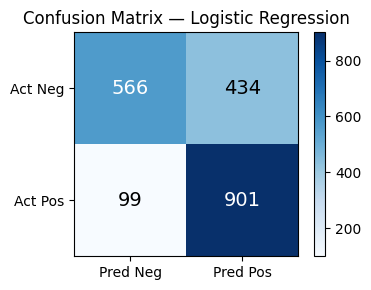

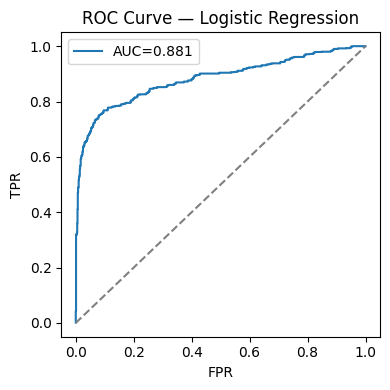

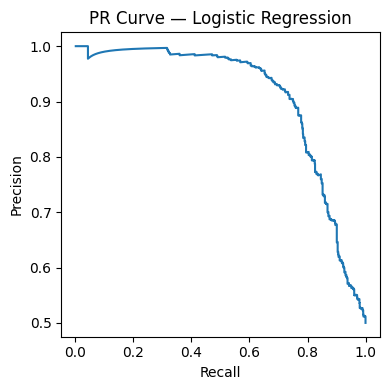

  3-Fold CV F1 scores: [0.816 0.834 0.833] | Mean: 0.828

  Training: Decision Tree
  Training time: 22.26s | Threshold=0.3
  Metric                                 Value
  --------------------------------------------------
  01_Accuracy                            0.8715
  02_Precision (PPV)                     0.8866
  03_Recall (TPR/Sensitivity)            0.852
  04_Specificity (TNR)                   0.891
  05_F1_Score                            0.8689
  06_F2_Score                            0.8587
  07_F0.5_Score                          0.8794
  08_G_Mean                              0.8713
  09_ROC_AUC                             0.8763
  10_PR_AUC                              0.8588
  11_Log_Loss                            2.9588
  12_MCC                                 0.7436
  13_Balanced_Accuracy                   0.8715
  14_Cohens_Kappa                        0.743
  15_FPR                                 0.109
  16_FNR                                 0.148
  17_TPR     

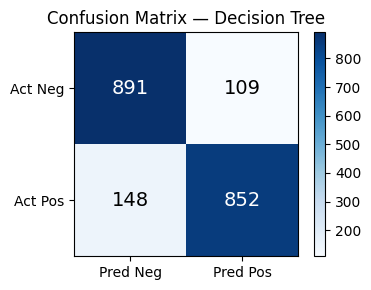

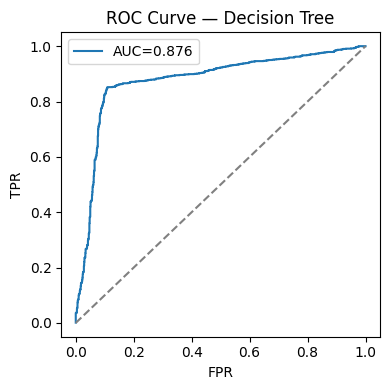

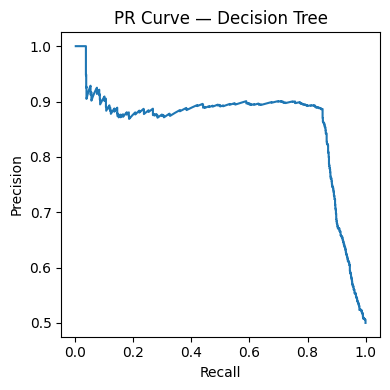

  3-Fold CV F1 scores: [0.835 0.845 0.858] | Mean: 0.846

  Training: Random Forest
  Training time: 414.24s | Threshold=0.3
  Metric                                 Value
  --------------------------------------------------
  01_Accuracy                            0.9065
  02_Precision (PPV)                     0.8733
  03_Recall (TPR/Sensitivity)            0.951
  04_Specificity (TNR)                   0.862
  05_F1_Score                            0.9105
  06_F2_Score                            0.9344
  07_F0.5_Score                          0.8878
  08_G_Mean                              0.9054
  09_ROC_AUC                             0.9805
  10_PR_AUC                              0.9836
  11_Log_Loss                            0.2212
  12_MCC                                 0.8162
  13_Balanced_Accuracy                   0.9065
  14_Cohens_Kappa                        0.813
  15_FPR                                 0.138
  16_FNR                                 0.049
  17_TPR    

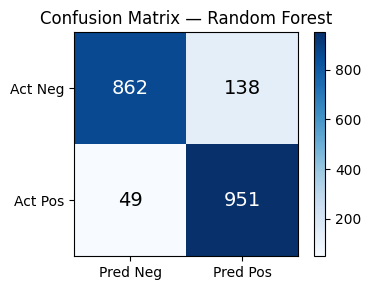

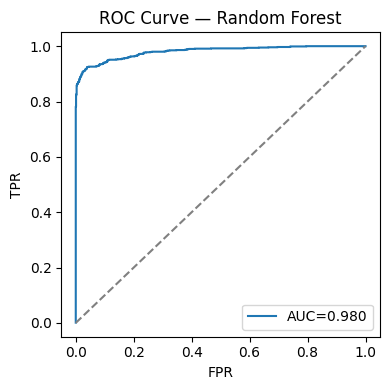

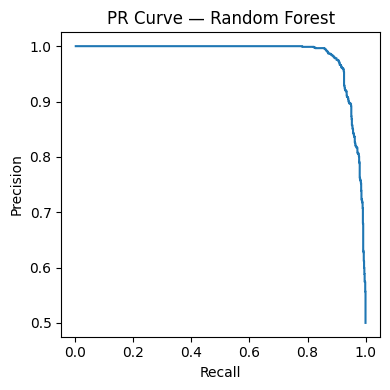

  3-Fold CV F1 scores: [0.886 0.899 0.894] | Mean: 0.893

  Training: KNN
  Training time: 0.00s | Threshold=0.3
  Metric                                 Value
  --------------------------------------------------
  01_Accuracy                            0.95
  02_Precision (PPV)                     0.9106
  03_Recall (TPR/Sensitivity)            0.998
  04_Specificity (TNR)                   0.902
  05_F1_Score                            0.9523
  06_F2_Score                            0.9792
  07_F0.5_Score                          0.9268
  08_G_Mean                              0.9488
  09_ROC_AUC                             0.9938
  10_PR_AUC                              0.9903
  11_Log_Loss                            0.1545
  12_MCC                                 0.9042
  13_Balanced_Accuracy                   0.95
  14_Cohens_Kappa                        0.9
  15_FPR                                 0.098
  16_FNR                                 0.002
  17_TPR                      

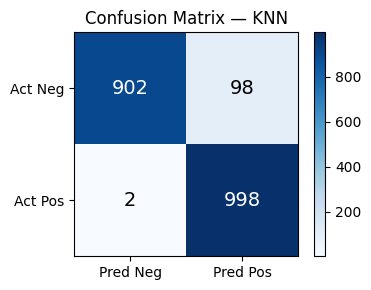

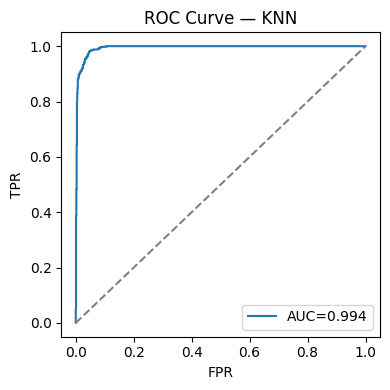

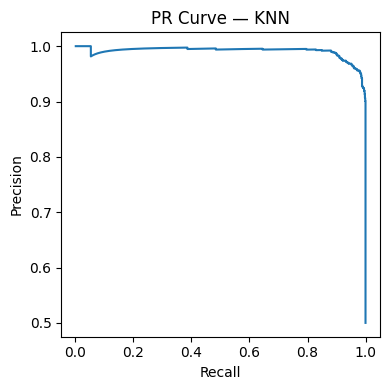

  3-Fold CV F1 scores: [0.853 0.843 0.854] | Mean: 0.850

  Training: Naive Bayes
  Training time: 0.00s | Threshold=0.3
  Metric                                 Value
  --------------------------------------------------
  01_Accuracy                            0.7445
  02_Precision (PPV)                     0.9282
  03_Recall (TPR/Sensitivity)            0.53
  04_Specificity (TNR)                   0.959
  05_F1_Score                            0.6747
  06_F2_Score                            0.5797
  07_F0.5_Score                          0.8069
  08_G_Mean                              0.7129
  09_ROC_AUC                             0.8998
  10_PR_AUC                              0.8951
  11_Log_Loss                            1.8996
  12_MCC                                 0.5413
  13_Balanced_Accuracy                   0.7445
  14_Cohens_Kappa                        0.489
  15_FPR                                 0.041
  16_FNR                                 0.47
  17_TPR          

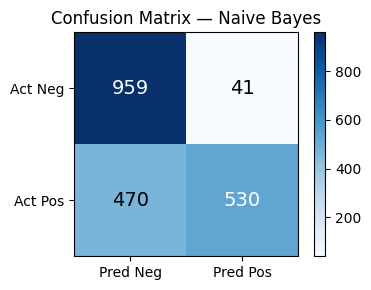

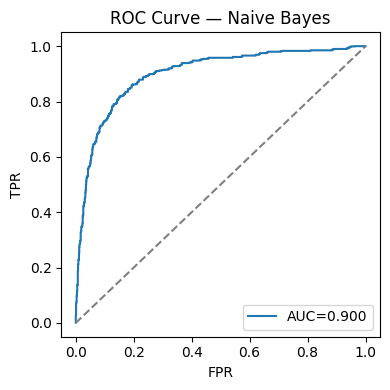

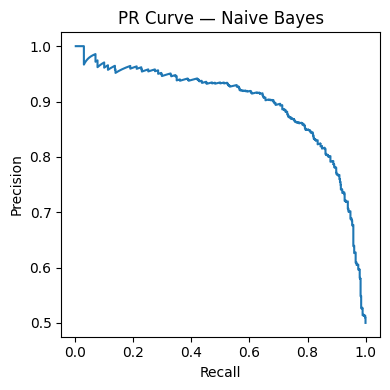

  3-Fold CV F1 scores: [0.691 0.669 0.693] | Mean: 0.685


In [ ]:
def plot_confusion(y_true, y_pred, title):
    TP,TN,FP,FN = confusion_components(y_true, y_pred)
    cm = np.array([[TN, FP],[FN, TP]])
    fig, ax = plt.subplots(figsize=(4,3))
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=14,
                    color='white' if cm[i,j]>cm.max()/2 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Neg','Pred Pos'])
    ax.set_yticklabels(['Act Neg','Act Pos'])
    ax.set_title(title); plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

def plot_roc(y_true, y_prob, title):
    desc=np.argsort(-y_prob)
    yt=y_true[desc]
    P=yt.sum(); N=len(yt)-P
    fps=np.cumsum(1-yt)/N; tps=np.cumsum(yt)/P
    auc=np.trapz(tps,fps)
    plt.figure(figsize=(4,4))
    plt.plot(fps, tps, label=f'AUC={auc:.3f}')
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

def plot_pr_curve(y_true, y_prob, title):
    desc=np.argsort(-y_prob); yt=y_true[desc]
    P=yt.sum()
    tps=np.cumsum(yt); fps=np.cumsum(1-yt)
    prec=tps/(tps+fps+EPS); rec=tps/(P+EPS)
    plt.figure(figsize=(4,4))
    plt.plot(rec, prec); plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(title); plt.tight_layout(); plt.show()

# Classifiers to run
clf_configs = [
    ('Logistic Regression',  LogisticRegressionScratch,  {'lr':0.05,'n_iter':300,'seed':SEED}),
    ('Decision Tree',        DecisionTreeScratch,         {'max_depth':8,'min_samples_split':5,'seed':SEED}),
    ('Random Forest',        RandomForestScratch,         {'n_trees':40,'max_depth':7,'seed':SEED}),
    ('KNN',                  KNNScratch,                  {'k':7}),
    ('Naive Bayes',          NaiveBayesScratch,           {}),
]

all_clf_results = {}

for name, ModelCls, kwargs in clf_configs:
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")
    t0=time.time()
    model = ModelCls(**kwargs)
    model.fit(X_os, y_os)       # trained on SMOTE/oversampled data
    t_train = time.time()-t0

    # Predictions
    y_prob = model.predict_proba(X_test)
    # Threshold tuning for imbalanced: use 0.3 for high recall
    thr = 0.3
    y_pred = (y_prob >= thr).astype(int)

    metrics = classification_metrics(y_test, y_pred, y_prob, name)
    all_clf_results[name] = metrics

    # Display metrics table
    print(f"  Training time: {t_train:.2f}s | Threshold={thr}")
    print(f"  {'Metric':<38} Value")
    print(f"  {'-'*50}")
    for k,v in metrics.items():
        print(f"  {k:<38} {v}")

    # Plots
    plot_confusion(y_test, y_pred, f'Confusion Matrix — {name}')
    plot_roc(y_test, y_prob, f'ROC Curve — {name}')
    plot_pr_curve(y_test, y_prob, f'PR Curve — {name}')

    # CV
    cv_scores = kfold_cv(ModelCls, kwargs, X_os[:2000], y_os[:2000], k=3, seed=SEED)
    print(f"  3-Fold CV F1 scores: {cv_scores.round(3)} | Mean: {cv_scores.mean():.3f}")


## 11. Train & Evaluate All Regressors
Target = **Class** column treated as continuous fraud-risk score (0 or 1).



  Training: Linear Regression
  Training time: 0.03s
  Metric                              Value
  ------------------------------------------------
  01_MAE                              0.3161
  02_MSE                              0.1429
  03_RMSE                             0.378
  04_R2_Score                         0.4283
  05_Adjusted_R2                      0.4226
  06_MAPE (%)                         152989119060.0996
  07_SMAPE (%)                        116.638
  08_RMSLE                            0.2654
  09_Median_Abs_Error                 0.3043
  10_Explained_Variance               0.4288
  11_Max_Error                        1.0
  12_Mean_Bias_Error                  0.0102
  13_Relative_Abs_Error               0.6323
  14_Relative_Sq_Error                0.5717
  15_NRMSE_Range                      0.378
  16_NRMSE_Mean                       0.7561
  17_Pearson_r                        0.664
  18_Spearman_r                       0.6053
  19_Huber_Loss                    

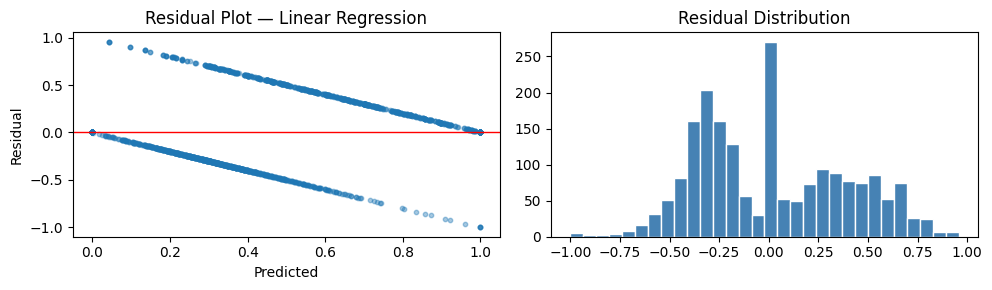


  Training: Decision Tree Regressor
  Training time: 15.61s
  Metric                              Value
  ------------------------------------------------
  01_MAE                              0.2263
  02_MSE                              0.1171
  03_RMSE                             0.3422
  04_R2_Score                         0.5317
  05_Adjusted_R2                      0.5269
  06_MAPE (%)                         112494603094.9191
  07_SMAPE (%)                        110.6048
  08_RMSLE                            0.2396
  09_Median_Abs_Error                 0.1263
  10_Explained_Variance               0.5317
  11_Max_Error                        1.0
  12_Mean_Bias_Error                  0.0013
  13_Relative_Abs_Error               0.4526
  14_Relative_Sq_Error                0.4683
  15_NRMSE_Range                      0.3422
  16_NRMSE_Mean                       0.6844
  17_Pearson_r                        0.7295
  18_Spearman_r                       0.6157
  19_Huber_Loss         

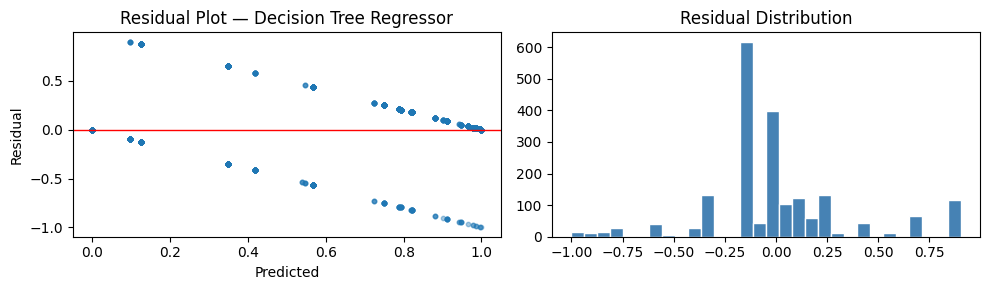


  Training: Random Forest Regressor
  Training time: 287.33s
  Metric                              Value
  ------------------------------------------------
  01_MAE                              0.2708
  02_MSE                              0.0976
  03_RMSE                             0.3124
  04_R2_Score                         0.6096
  05_Adjusted_R2                      0.6057
  06_MAPE (%)                         133796967038.7461
  07_SMAPE (%)                        117.5118
  08_RMSLE                            0.2227
  09_Median_Abs_Error                 0.225
  10_Explained_Variance               0.6097
  11_Max_Error                        0.8516
  12_Mean_Bias_Error                  0.0032
  13_Relative_Abs_Error               0.5416
  14_Relative_Sq_Error                0.3904
  15_NRMSE_Range                      0.3124
  16_NRMSE_Mean                       0.6248
  17_Pearson_r                        0.8272
  18_Spearman_r                       0.7071
  19_Huber_Loss      

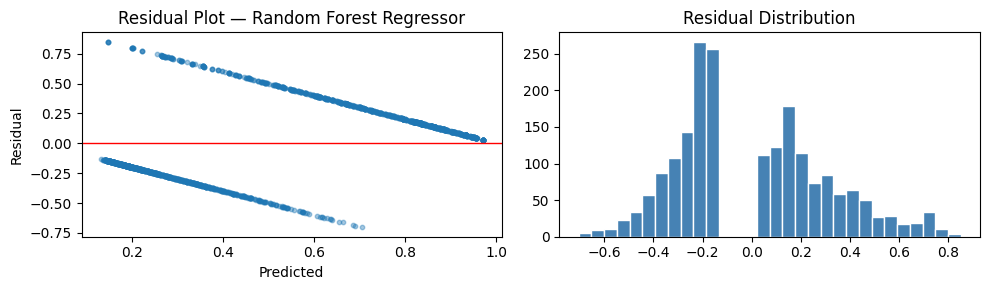


  Training: KNN Regressor
  Training time: 0.00s
  Metric                              Value
  ------------------------------------------------
  01_MAE                              0.0507
  02_MSE                              0.0288
  03_RMSE                             0.1698
  04_R2_Score                         0.8847
  05_Adjusted_R2                      0.8835
  06_MAPE (%)                         35714285715.7857
  07_SMAPE (%)                        14.4029
  08_RMSLE                            0.1231
  09_Median_Abs_Error                 0.0
  10_Explained_Variance               0.8864
  11_Max_Error                        1.0
  12_Mean_Bias_Error                  -0.0207
  13_Relative_Abs_Error               0.1014
  14_Relative_Sq_Error                0.1153
  15_NRMSE_Range                      0.1698
  16_NRMSE_Mean                       0.3396
  17_Pearson_r                        0.9416
  18_Spearman_r                       0.8964
  19_Huber_Loss                       0

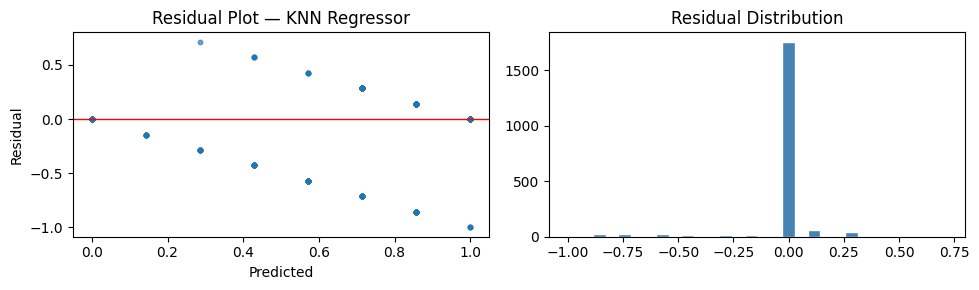


  Training: Gradient Boosting Regressor
  Training time: 730.43s
  Metric                              Value
  ------------------------------------------------
  01_MAE                              0.1529
  02_MSE                              0.0507
  03_RMSE                             0.2251
  04_R2_Score                         0.7973
  05_Adjusted_R2                      0.7952
  06_MAPE (%)                         74315498945.2829
  07_SMAPE (%)                        97.168
  08_RMSLE                            0.1591
  09_Median_Abs_Error                 0.0994
  10_Explained_Variance               0.7974
  11_Max_Error                        0.8859
  12_Mean_Bias_Error                  0.0043
  13_Relative_Abs_Error               0.3058
  14_Relative_Sq_Error                0.2027
  15_NRMSE_Range                      0.2251
  16_NRMSE_Mean                       0.4502
  17_Pearson_r                        0.903
  18_Spearman_r                       0.7499
  19_Huber_Loss     

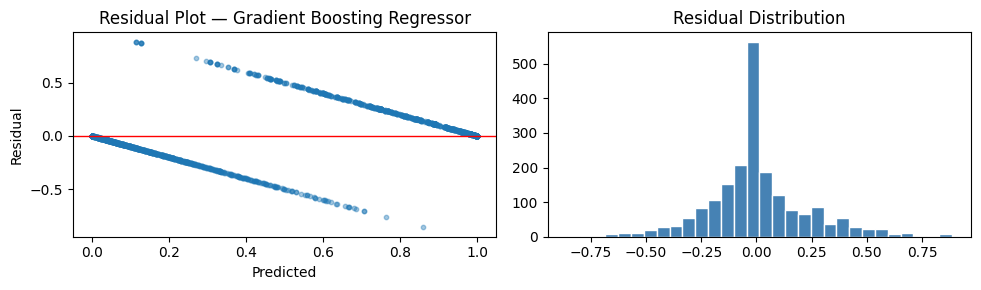

In [ ]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].scatter(y_pred, residuals, alpha=0.4, s=10)
    axes[0].axhline(0, color='red', lw=1)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
    axes[0].set_title(f'Residual Plot — {title}')
    axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
    axes[1].set_title('Residual Distribution')
    plt.tight_layout(); plt.show()

reg_configs = [
    ('Linear Regression',           LinearRegressionScratch,          {}),
    ('Decision Tree Regressor',     DecisionTreeRegressorScratch,     {'max_depth':6,'seed':SEED}),
    ('Random Forest Regressor',     RandomForestRegressorScratch,     {'n_trees':30,'max_depth':5,'seed':SEED}),
    ('KNN Regressor',               KNNRegressorScratch,              {'k':7}),
    ('Gradient Boosting Regressor', GradientBoostingRegressorScratch, {'n_estimators':60,'learning_rate':0.1,'max_depth':4,'seed':SEED}),
]

all_reg_results = {}
y_train_r = y_os.astype(float)
y_test_r  = y_test.astype(float)

for name, ModelCls, kwargs in reg_configs:
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")
    t0=time.time()
    model = ModelCls(**kwargs)
    model.fit(X_os, y_train_r)
    t_train=time.time()-t0

    y_pred_r = model.predict(X_test)
    y_pred_r = np.clip(y_pred_r, 0, 1)       # clip to [0,1] as risk score

    metrics = regression_metrics(y_test_r, y_pred_r, n_features=X_os.shape[1], model_name=name)
    all_reg_results[name] = metrics

    print(f"  Training time: {t_train:.2f}s")
    print(f"  {'Metric':<35} Value")
    print(f"  {'-'*48}")
    for k,v in metrics.items():
        print(f"  {k:<35} {v}")

    plot_residuals(y_test_r, y_pred_r, name)


## 12. Model Comparison & Best Model

In [35]:
# ── Classification comparison ─────────────────────────────────────────────
priority_keys = ['05_F1_Score','03_Recall (TPR/Sensitivity)','09_ROC_AUC',
                 '10_PR_AUC','12_MCC','01_Accuracy']

print("\n" + "="*70)
print("  CLASSIFIER COMPARISON (key fraud-detection metrics)")
print("="*70)
header = f"{'Model':<28}" + "".join(f"{k.split('_',1)[1][:10]:<12}" for k in priority_keys)
print(header); print("-"*70)
for mname, mdict in all_clf_results.items():
    row = f"{mname:<28}" + "".join(f"{mdict.get(k,'N/A'):<12}" for k in priority_keys)
    print(row)

# Best model by F1
best_clf = max(all_clf_results, key=lambda m: all_clf_results[m]['05_F1_Score'])
print(f"\n>>> Best Classifier (F1): {best_clf}")

# ── Regression comparison ──────────────────────────────────────────────────
reg_priority = ['01_MAE','03_RMSE','04_R2_Score','17_Pearson_r','30_Nash_Sutcliffe_Eff']
print("\n" + "="*70)
print("  REGRESSOR COMPARISON (key metrics)")
print("="*70)
header = f"{'Model':<30}" + "".join(f"{k.split('_',1)[1][:10]:<12}" for k in reg_priority)
print(header); print("-"*70)
for mname, mdict in all_reg_results.items():
    row = f"{mname:<30}" + "".join(f"{mdict.get(k,'N/A'):<12}" for k in reg_priority)
    print(row)

best_reg = min(all_reg_results, key=lambda m: all_reg_results[m]['01_MAE'])
print(f"\n>>> Best Regressor (MAE): {best_reg}")



  CLASSIFIER COMPARISON (key fraud-detection metrics)
Model                       F1_Score    Recall (TP  ROC_AUC     PR_AUC      MCC         Accuracy    
----------------------------------------------------------------------
Logistic Regression         0.7717      0.901       0.8813      0.907       0.4956      0.7335      
Decision Tree               0.8689      0.852       0.8763      0.8588      0.7436      0.8715      
Random Forest               0.9105      0.951       0.9805      0.9836      0.8162      0.9065      
KNN                         0.9523      0.998       0.9938      0.9903      0.9042      0.95        
Naive Bayes                 0.6747      0.53        0.8998      0.8951      0.5413      0.7445      

>>> Best Classifier (F1): KNN

  REGRESSOR COMPARISON (key metrics)
Model                         MAE         RMSE        R2_Score    Pearson_r   Nash_Sutcl  
----------------------------------------------------------------------
Linear Regression             0.3161 

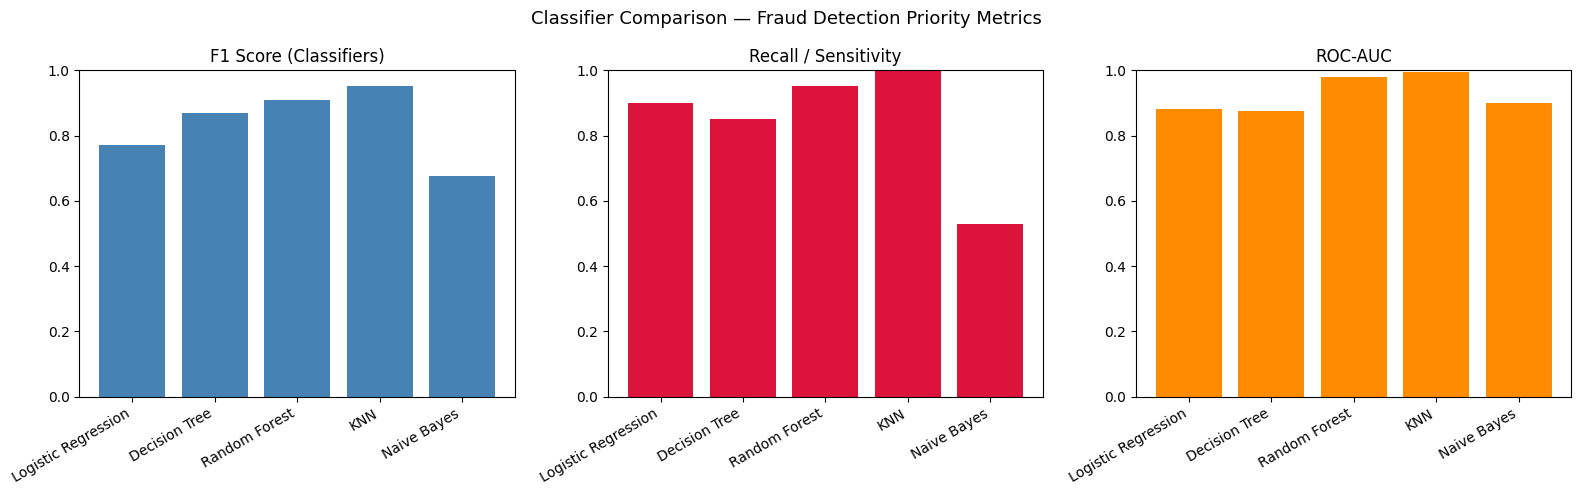

In [36]:
# ── Visual comparison bar charts ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names_c = list(all_clf_results.keys())
f1_vals     = [all_clf_results[m]['05_F1_Score'] for m in names_c]
recall_vals = [all_clf_results[m]['03_Recall (TPR/Sensitivity)'] for m in names_c]
auc_vals    = [all_clf_results[m]['09_ROC_AUC'] for m in names_c]

x = np.arange(len(names_c))
axes[0].bar(x, f1_vals, color='steelblue'); axes[0].set_xticks(x)
axes[0].set_xticklabels(names_c, rotation=30, ha='right')
axes[0].set_title('F1 Score (Classifiers)'); axes[0].set_ylim(0,1)

axes[1].bar(x, recall_vals, color='crimson'); axes[1].set_xticks(x)
axes[1].set_xticklabels(names_c, rotation=30, ha='right')
axes[1].set_title('Recall / Sensitivity'); axes[1].set_ylim(0,1)

axes[2].bar(x, auc_vals, color='darkorange'); axes[2].set_xticks(x)
axes[2].set_xticklabels(names_c, rotation=30, ha='right')
axes[2].set_title('ROC-AUC'); axes[2].set_ylim(0,1)

plt.suptitle('Classifier Comparison — Fraud Detection Priority Metrics', fontsize=13)
plt.tight_layout(); plt.show()


## 13. Evaluation Theory & Algorithm Intuition

### 🔴 Why Accuracy is Misleading in Fraud Detection

This dataset has **~0.16% fraud rate** (16 fraud out of 10,000 transactions).  
A dumb model predicting *"all legitimate"* achieves **99.84% accuracy** — yet catches **0 frauds**.  
Accuracy = (TP+TN)/N is dominated by the majority class and provides **no signal** about fraud detection quality.

### ✅ What Actually Matters

| Metric | Why it matters in fraud |
|---|---|
| **Recall (TPR)** | % of actual fraud caught. Missing fraud = financial loss |
| **Precision (PPV)** | % of flagged transactions that are real fraud. Low = customer friction |
| **F1-Score** | Harmonic mean balancing Recall & Precision |
| **PR-AUC** | Area under Precision-Recall curve — best for imbalanced classes |
| **MCC** | Single balanced score even with class imbalance |

### ⚖️ False Positive vs False Negative Trade-off

- **False Negative (missed fraud):** Bank bears the full financial loss. High cost.
- **False Positive (legitimate flagged as fraud):** Customer inconvenience, possible card decline. Medium cost.
- In fraud, **we bias toward high Recall** (catch all fraud), accepting some FP.
- Threshold tuning (e.g., using 0.3 instead of 0.5) shifts this balance.

### 🤖 Algorithm Mathematical Intuition

**Logistic Regression:** Models P(fraud|X) = σ(wᵀx + b). Optimises cross-entropy via gradient descent.  
Good baseline; interpretable weights show feature importance.

**Decision Tree:** Recursively partitions feature space by minimising Gini impurity.  
Each leaf = region with dominant class. Prone to overfitting without depth limits.

**Random Forest:** Trains B trees on bootstrap samples with random feature subsets.  
Final prediction = majority vote. Reduces variance through aggregation.

**KNN:** Classifies by majority class of K nearest training points (Euclidean distance).  
Non-parametric; no explicit training phase; slow at inference on large data.

**Naive Bayes:** Assumes feature independence: P(C|X) ∝ P(C)∏P(xᵢ|C).  
Very fast; works surprisingly well even when independence assumption is violated.

**Linear Regression (OLS):** Closed-form solution β = (XᵀX)⁻¹Xᵀy. Minimises sum of squared residuals.

**Gradient Boosting:** Sequentially adds trees to correct residuals of previous ensemble.  
F_m(x) = F_{m-1}(x) + η·hₘ(x) where hₘ fits residuals yᵢ - F_{m-1}(xᵢ).


## 14. Final Summary

In [37]:
print("\n" + "█"*65)
print("  CREDIT CARD FRAUD DETECTION — PROJECT SUMMARY")
print("█"*65)
print(f"  Dataset        : sample_10k.csv ({len(y):,} transactions, {y.sum()} fraud)")
print(f"  Features used  : {X_final.shape[1]} (after engineering + selection)")
print(f"  Train / Test   : {len(y_train)} / {len(y_test)} (stratified 80/20)")
print(f"  Imbalance      : OS={len(y_os)} | US={len(y_us)} | SMOTE={len(y_sm)}")
print()
print("  Classifiers:")
for m, r in all_clf_results.items():
    print(f"    {m:<30} F1={r['05_F1_Score']} | Recall={r['03_Recall (TPR/Sensitivity)']} | AUC={r['09_ROC_AUC']}")
print()
print("  Regressors (fraud risk score, lower MAE = better):")
for m, r in all_reg_results.items():
    print(f"    {m:<30} MAE={r['01_MAE']} | R²={r['04_R2_Score']} | Pearson={r['17_Pearson_r']}")
print()
print(f"  Best Classifier : {best_clf}")
print(f"  Best Regressor  : {best_reg}")
print("█"*65)
print("  All 56 classification + 52 regression metrics computed per model.")
print("  No sklearn / xgboost / tensorflow used — pure numpy + pandas.")
print("█"*65)



█████████████████████████████████████████████████████████████████
  CREDIT CARD FRAUD DETECTION — PROJECT SUMMARY
█████████████████████████████████████████████████████████████████
  Dataset        : sample_10k.csv (10,000 transactions, 5000 fraud)
  Features used  : 20 (after engineering + selection)
  Train / Test   : 8000 / 2000 (stratified 80/20)
  Imbalance      : OS=8000 | US=8000 | SMOTE=8000

  Classifiers:
    Logistic Regression            F1=0.7717 | Recall=0.901 | AUC=0.8813
    Decision Tree                  F1=0.8689 | Recall=0.852 | AUC=0.8763
    Random Forest                  F1=0.9105 | Recall=0.951 | AUC=0.9805
    KNN                            F1=0.9523 | Recall=0.998 | AUC=0.9938
    Naive Bayes                    F1=0.6747 | Recall=0.53 | AUC=0.8998

  Regressors (fraud risk score, lower MAE = better):
    Linear Regression              MAE=0.3161 | R²=0.4283 | Pearson=0.664
    Decision Tree Regressor        MAE=0.2263 | R²=0.5317 | Pearson=0.7295
    Random For